In [ ]:
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
print('Setup complete. pandas', pd.__version__)

Setup complete. pandas 2.2.2


In [ ]:
df = pd.DataFrame({
    'city':   ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'size':   ['small', 'large', 'medium', 'medium', 'small', 'large', 'large', 'small'],
    'age':    [25, 41, 33, 29, 52, 38, 46, 22],
    'income': [38000, 92000, 55000, 47000, 120000, 76000, 88000, 41000],
    'bought': [0, 1, 0, 0, 1, 1, 1, 0],   # target
})
df

,city,size,age,income,bought
0,pune,small,25,38000,0
1,delhi,large,41,92000,1
2,mumbai,medium,33,55000,0
3,pune,medium,29,47000,0
4,delhi,small,52,120000,1
5,mumbai,large,38,76000,1
6,pune,large,46,88000,1
7,delhi,small,22,41000,0


In [ ]:
city_ohe = pd.get_dummies(df['city'], prefix='city').astype(int)
city_ohe
size_order = {'small': 0, 'medium': 1, 'large': 2}
df['size_code'] = df['size'].map(size_order)
df[['size', 'size_code']]

,size,size_code
0,small,0
1,large,2
2,medium,1
3,medium,1
4,small,0
5,large,2
6,large,2
7,small,0


In [ ]:
import pandas as pd

# Sample data
df = pd.DataFrame({
    'city': ['Delhi', 'Mumbai', 'Chennai', 'Delhi'],
    'size': ['Small', 'Medium', 'Large', 'Medium']
})

# Ordinal encoding for size
size_order = {'Small': 0, 'Medium': 1, 'Large': 2}
df['size_code'] = df['size'].map(size_order)

# One-hot encode city on the whole DataFrame
df_encoded = pd.get_dummies(df, columns=['city'])

print(df_encoded)


     size  size_code  city_Chennai  city_Delhi  city_Mumbai
0   Small          0         False        True        False
1  Medium          1         False       False         True
2   Large          2          True       False        False
3  Medium          1         False        True        False


In [ ]:
import pandas as pd

# Re-initialize df to ensure 'city' column is present
df = pd.DataFrame({
    'city': ['Delhi', 'Mumbai', 'Chennai', 'Delhi'],
    'size': ['Small', 'Medium', 'Large', 'Medium']
})

# 1. one-hot encode just the 'city' column of the whole df
df = pd.get_dummies(df, columns=['city'])

# 2. ordinal-encode 'size' (map with size_order)
size_order = {'Small': 0, 'Medium': 1, 'Large': 2}
df['size_code'] = df['size'].map(size_order)

### Label Encoding with Scikit-Learn

Label encoding assigns a unique integer to each category based on the order of appearance or alphabetical order. It's often used for target variables or for features where the ordinal relationship doesn't matter, or where a specific ordinal relationship is *not* desired (as one-hot encoding would be more appropriate for nominal features without order).

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the original df to demonstrate label encoding without affecting previous examples
# The original df from cell IxRGQROXUXcD is suitable as it has both 'city' and 'size' in their original categorical form.
df_le = pd.DataFrame({
    'city':   ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'size':   ['small', 'large', 'medium', 'medium', 'small', 'large', 'large', 'small'],
    'age':    [25, 41, 33, 29, 52, 38, 46, 22],
    'income': [38000, 92000, 55000, 47000, 120000, 76000, 88000, 41000],
    'bought': [0, 1, 0, 0, 1, 1, 1, 0],   # target
})

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to 'city' column
df_le['city_encoded'] = le.fit_transform(df_le['city'])
print('City categories and their encoded values:')
for i, item in enumerate(le.classes_):
    print(f"{item}: {i}")

# Apply Label Encoding to 'size' column
df_le['size_encoded'] = le.fit_transform(df_le['size'])
print('\nSize categories and their encoded values:')
for i, item in enumerate(le.classes_):
    print(f"{item}: {i}")

display(df_le[['city', 'city_encoded', 'size', 'size_encoded']])

City categories and their encoded values:
delhi: 0
mumbai: 1
pune: 2

Size categories and their encoded values:
large: 0
medium: 1
small: 2


,city,city_encoded,size,size_encoded
0,pune,2,small,2
1,delhi,0,large,0
2,mumbai,1,medium,1
3,pune,2,medium,1
4,delhi,0,small,2
5,mumbai,1,large,0
6,pune,2,large,0
7,delhi,0,small,2


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Re-initialize df with original data to ensure 'age' and 'income' columns are present
df = pd.DataFrame({
    'city':   ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'size':   ['small', 'large', 'medium', 'medium', 'small', 'large', 'large', 'small'],
    'age':    [25, 41, 33, 29, 52, 38, 46, 22],
    'income': [38000, 92000, 55000, 47000, 120000, 76000, 88000, 41000],
    'bought': [0, 1, 0, 0, 1, 1, 1, 0],   # target
})

# -----------------------------------------------------------
# 🔹 2A. THE PROBLEM — FEATURES ON DIFFERENT SCALES
# -----------------------------------------------------------

# income (tens of thousands) dwarfs age (tens). A distance-based
# model would treat income as nearly all that matters.
print(df[['age', 'income']].describe().loc[['min', 'max', 'mean']])


# -----------------------------------------------------------
# 🔹 2B. STANDARDISATION (Z-score)  vs  NORMALISATION (Min-Max)
# -----------------------------------------------------------

num = df[['age', 'income']]

z = StandardScaler().fit_transform(num)        # mean 0, std 1
m = MinMaxScaler().fit_transform(num)          # range [0, 1]

print('Standardised (mean~0, std~1):')
print(pd.DataFrame(z, columns=['age', 'income']).round(2).head(3))
print('\nMin-Max (range 0..1):')
print(pd.DataFrame(m, columns=['age', 'income']).round(2).head(3))

        age    income
min   22.00   38000.0
max   52.00  120000.0
mean  35.75   69625.0
Standardised (mean~0, std~1):
    age  income
0 -1.10   -1.16
1  0.54    0.82
2 -0.28   -0.54

Min-Max (range 0..1):
    age  income
0  0.10    0.00
1  0.63    0.66
2  0.37    0.21


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

income = df[['income']]   # 2D shape for sklearn

# 1. standardise -> check mean ~0, std ~1
std_scaler = StandardScaler()
income_std = std_scaler.fit_transform(income)

print("Mean after standardisation:", income_std.mean())
print("Std after standardisation :", income_std.std())

# 2. min-max scale -> check min 0, max 1
mm_scaler = MinMaxScaler()
income_mm = mm_scaler.fit_transform(income)

print("Min after Min-Max scaling:", income_mm.min())
print("Max after Min-Max scaling:", income_mm.max())

Mean after standardisation: -2.7755575615628914e-17
Std after standardisation : 1.0
Min after Min-Max scaling: 0.0
Max after Min-Max scaling: 1.0000000000000002


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. SPLIT FIRST, THEN FIT ON TRAIN ONLY
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['age', 'income']]
y = df['bought']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # FIT + transform on train
X_test_s  = scaler.transform(X_test)        # only TRANSFORM on test
print('train rows:', X_train.shape[0], '| test rows:', X_test.shape[0])
print('scaler learned mean from TRAIN only:', scaler.mean_.round(1))

train rows: 6 | test rows: 2
scaler learned mean from TRAIN only: [3.45e+01 6.90e+04]


In [ ]:
from sklearn.preprocessing import StandardScaler

# 1a. WRONG: fit on ALL data, then split (leakage!)
wrong_mean = StandardScaler().fit(X).mean_

# 1b. RIGHT: fit on TRAIN only
right_mean = StandardScaler().fit(X_train).mean_

print('fit-on-all mean :', wrong_mean.round(1))
print('fit-on-train mean:', right_mean.round(1))

fit-on-all mean : [3.5800e+01 6.9625e+04]
fit-on-train mean: [3.45e+01 6.90e+04]


In [ ]:
fe = df.copy()
# combine: income per year of age (a crude 'earning rate')
fe['income_per_age'] = (fe['income'] / fe['age']).round(0)
# bin: turn continuous age into life-stage buckets
fe['age_group'] = pd.cut(fe['age'], bins=[0, 30, 45, 100],
                         labels=['young', 'mid', 'senior'])
fe[['age', 'income', 'income_per_age', 'age_group']]


# -----------------------------------------------------------
# 🔹 4B. EXTRACT FROM A DATE
# -----------------------------------------------------------

dates = pd.to_datetime(['2024-01-06', '2024-03-15', '2024-07-21', '2024-12-25'])
d = pd.DataFrame({'date': dates})
d['day_of_week'] = d['date'].dt.day_name()   # Monday, Tuesday, ...
d['month']       = d['date'].dt.month
d['is_weekend']  = d['date'].dt.dayofweek >= 5
d

,date,day_of_week,month,is_weekend
0,2024-01-06,Saturday,1,True
1,2024-03-15,Friday,3,False
2,2024-07-21,Sunday,7,True
3,2024-12-25,Wednesday,12,False


In [ ]:
import pandas as pd

ex = df.copy()

# 1. high_earner flag (income > median)
median_income = ex['income'].median()
ex['high_earner'] = ex['income'] > median_income

# 2. bin income into 3 buckets with pd.cut
ex['income_bucket'] = pd.cut(
    ex['income'],
    bins=3,
    labels=['low', 'mid', 'high']
)

# 3. show income + the new columns
print(ex[['income', 'high_earner', 'income_bucket']])
# Explanation
# Step 1: Find Median Income
# median_income = ex['income'].median()
# Calculates the middle income value.
# Step 2: Create High Earner Flag
# ex['high_earner'] = ex['income'] > median_income
# Returns:
# True if income is above the median
# False otherwise

# Example:

# income	high_earner
# 30000	False
# 60000	True
# Step 3: Create Income Buckets
# ex['income_bucket'] = pd.cut(
#     ex['income'],
#     bins=3,
#     labels=['low', 'mid', 'high']
# )
# Divides the income range into 3 equal-width intervals.
# Assigns labels:
# low
# mid
# high

# Example:

# income	income_bucket
# 25000	low
# 50000	mid
# 85000	high
# Step 4: Display Selected Columns
# print(ex[['income', 'high_earner', 'income_bucket']])

   income  high_earner income_bucket
0   38000        False           low
1   92000         True           mid
2   55000        False           low
3   47000        False           low
4  120000         True          high
5   76000         True           mid
6   88000         True           mid
7   41000        False           low


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline


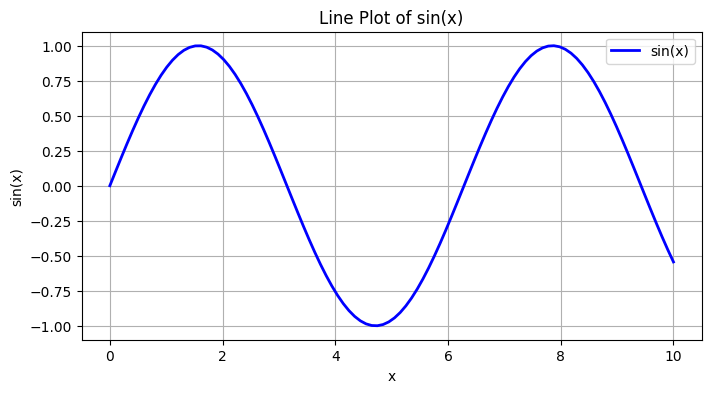

In [ ]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label='sin(x)', color='blue', linewidth=2)
plt.title('Line Plot of sin(x)')
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.grid(True)
plt.legend()
plt.show()

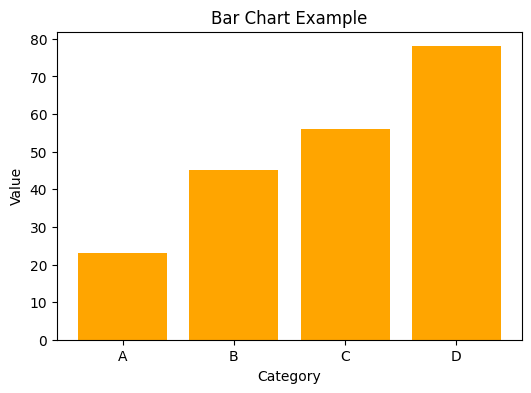

In [ ]:
categories = ['A', 'B', 'C', 'D']
values = [23, 45, 56, 78]

plt.figure(figsize=(6, 4))
plt.bar(categories, values, color='orange')
plt.title('Bar Chart Example')
plt.xlabel('Category')
plt.ylabel('Value')
plt.show()

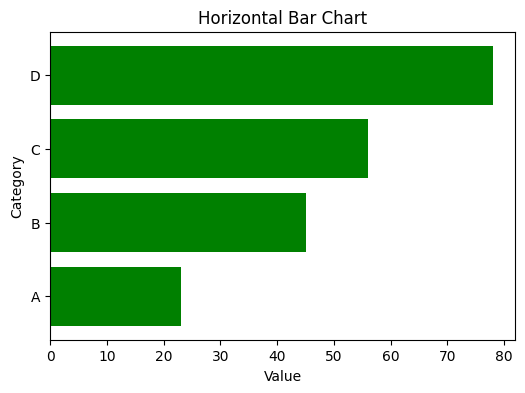

In [ ]:
plt.figure(figsize=(6, 4))
plt.barh(categories, values, color='green')
plt.title('Horizontal Bar Chart')
plt.xlabel('Value')
plt.ylabel('Category')
plt.show()

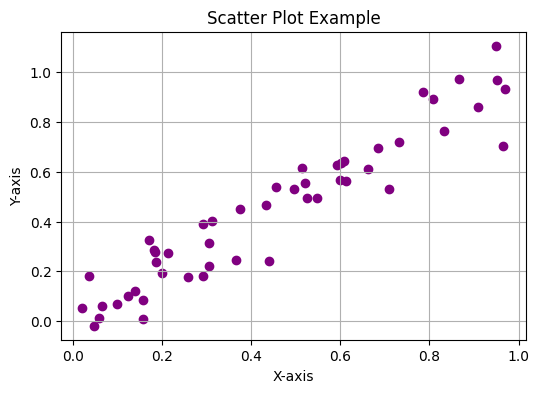

In [ ]:
np.random.seed(42)
x = np.random.rand(50)
y = x + np.random.normal(0, 0.1, 50)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='purple')
plt.title('Scatter Plot Example')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid(True)
plt.show()


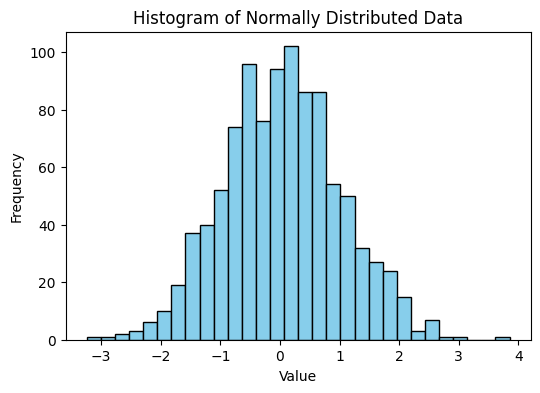

In [ ]:
data = np.random.randn(1000)

plt.figure(figsize=(6, 4))
plt.hist(data, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Normally Distributed Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

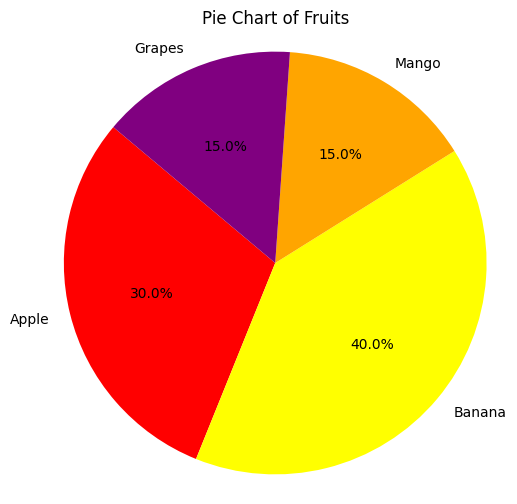

In [ ]:
sizes = [30, 40, 15, 15]
labels = ['Apple', 'Banana', 'Mango', 'Grapes']
colors = ['red', 'yellow', 'orange', 'purple']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of Fruits')
plt.axis('equal')
plt.show()

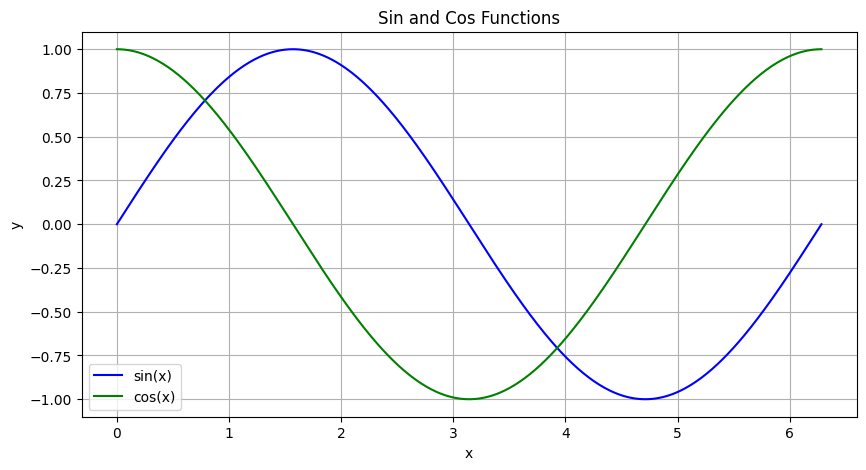

In [ ]:
x = np.linspace(0, 2 * np.pi, 400)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y1, label='sin(x)', color='blue')
plt.plot(x, y2, label='cos(x)', color='green')
plt.title('Sin and Cos Functions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

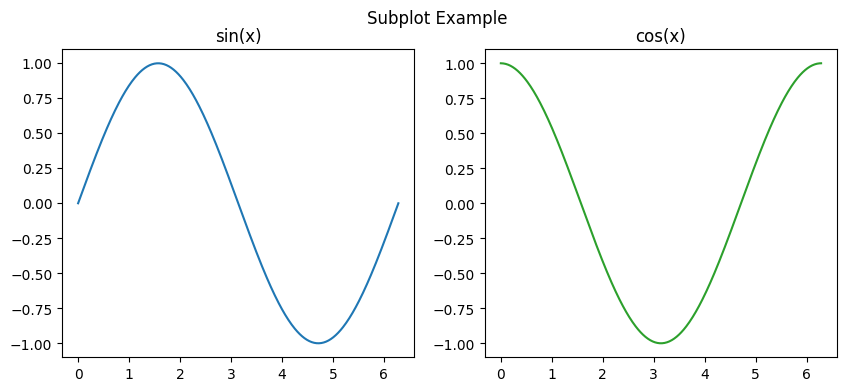

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(x, y1, 'tab:blue')
axs[0].set_title('sin(x)')
axs[1].plot(x, y2, 'tab:green')
axs[1].set_title('cos(x)')
plt.suptitle('Subplot Example')
plt.show()

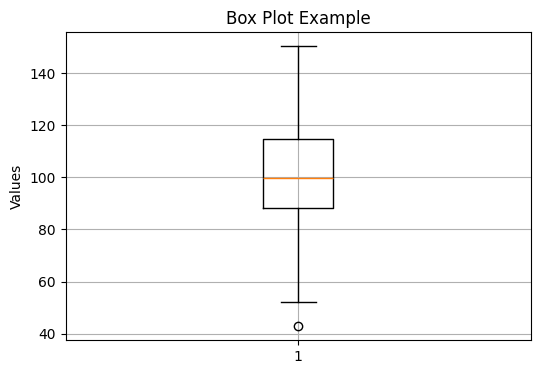

In [ ]:
np.random.seed(5)
data = np.random.normal(100, 20, 200)

plt.figure(figsize=(6, 4))
plt.boxplot(data, vert=True)
plt.title('Box Plot Example')
plt.ylabel('Values')
plt.grid(True)
plt.show()


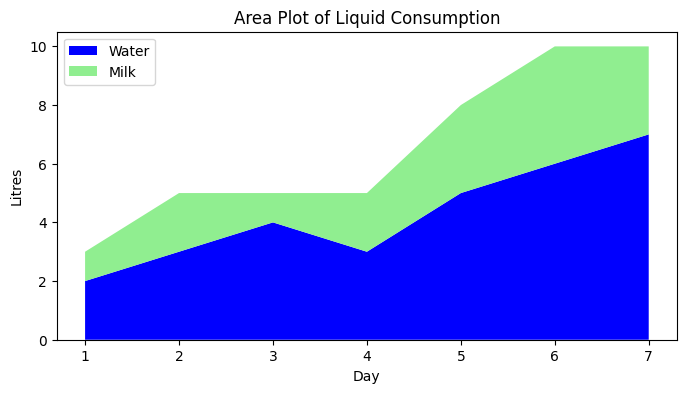

In [ ]:
days = np.arange(1, 8)
water = [2, 3, 4, 3, 5, 6, 7]
milk = [1, 2, 1, 2, 3, 4, 3]

plt.figure(figsize=(8, 4))
plt.stackplot(days, water, milk, labels=['Water', 'Milk'], colors=['blue', 'lightgreen'])
plt.title('Area Plot of Liquid Consumption')
plt.xlabel('Day')
plt.ylabel('Litres')
plt.legend()
plt.show()

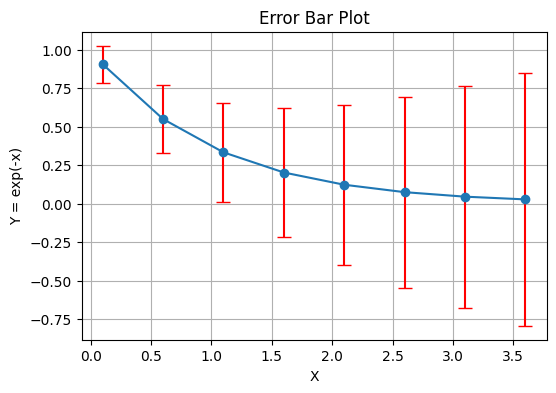

In [ ]:
x = np.arange(0.1, 4, 0.5)
y = np.exp(-x)
error = 0.1 + 0.2 * x

plt.figure(figsize=(6, 4))
plt.errorbar(x, y, yerr=error, fmt='-o', ecolor='red', capsize=5)
plt.title('Error Bar Plot')
plt.xlabel('X')
plt.ylabel('Y = exp(-x)')
plt.grid(True)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

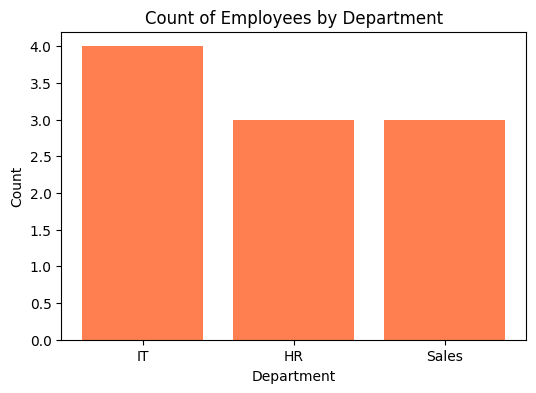

In [ ]:
category_data = pd.DataFrame({
    'Department': ['HR', 'IT', 'HR', 'Sales', 'Sales', 'IT', 'IT', 'HR', 'Sales', 'IT'],
    'Satisfaction': [3, 4, 2, 5, 4, 3, 4, 2, 5, 4]
})

# Count plot equivalent: Bar chart of value counts
dept_counts = category_data['Department'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(dept_counts.index, dept_counts.values, color='coral')
plt.title('Count of Employees by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.show

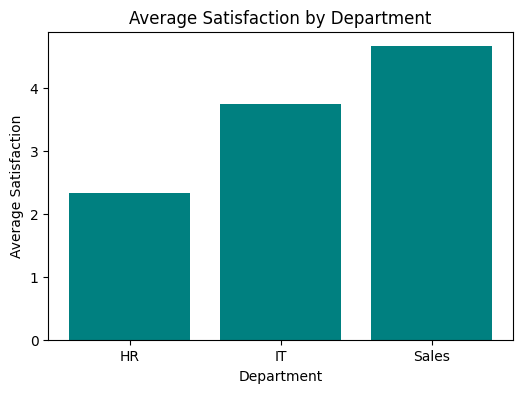

In [ ]:
mean_satisfaction = category_data.groupby('Department')['Satisfaction'].mean()
plt.figure(figsize=(6, 4))
plt.bar(mean_satisfaction.index, mean_satisfaction.values, color='teal')
plt.title('Average Satisfaction by Department')
plt.xlabel('Department')
plt.ylabel('Average Satisfaction')
plt.show()


In [ ]:
summary_data = {
    'Function': [
        'plt.plot()',
        'plt.bar()',
        'plt.barh()',
        'plt.scatter()',
        'plt.hist()',
        'plt.pie()',
        'plt.subplot()',
        'plt.subplots()',
        'plt.boxplot()',
        'plt.stackplot()',
        'plt.errorbar()',
        'plt.legend()',
        'plt.title()',
        'plt.xlabel()',
        'plt.ylabel()',
        'plt.grid()',
        'plt.show()'
    ],
    'Use Case': [
        'Line chart for continuous data',
        'Vertical bar chart',
        'Horizontal bar chart',
        'Scatter plot for relation between variables',
        'Histogram for distribution analysis',
        'Pie chart for categorical proportions',
        'Single subplot in a grid',
        'Multiple subplots layout',
        'Box plot for statistical summary (median, IQR)',
        'Area plot for stacked values',
        'Error bars to show confidence/uncertainty',
        'Add legend to a plot',
        'Set title of the plot',
        'Set label for X-axis',
        'Set label for Y-axis',
        'Enable gridlines',
        'Display the plot'
           ]
}
summary_df = pd.DataFrame(summary_data)
print("\n\n📌 Summary of Common matplotlib Functions:\n")
display(summary_df)



📌 Summary of Common matplotlib Functions:



,Function,Use Case
0,plt.plot(),Line chart for continuous data
1,plt.bar(),Vertical bar chart
2,plt.barh(),Horizontal bar chart
3,plt.scatter(),Scatter plot for relation between variables
4,plt.hist(),Histogram for distribution analysis
5,plt.pie(),Pie chart for categorical proportions
6,plt.subplot(),Single subplot in a grid
7,plt.subplots(),Multiple subplots layout
8,plt.boxplot(),"Box plot for statistical summary (median, IQR)"
9,plt.stackplot(),Area plot for stacked values


In [ ]:

# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()   # creates the two resource files locally
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')


# Load the customer table (parse the date columns as real datetimes)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('ecommerce_customers.csv',
                 parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
print('Loaded', df.shape[0], 'customers x', df.shape[1], 'columns')
df.head()

Generated dataset files.
Loaded 2500 customers x 15 columns


,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,plan,device,payment_method,num_orders,total_spend,support_tickets,email_opt_in,is_churned
0,CUST00001,2021-04-19,NaT,NaT,31.0,F,Chennai,Premium,Desktop,Card,0,0.00,2,0,0
1,CUST00002,2023-07-31,NaT,NaT,54.0,F,Hyderabad,Standard,Desktop,Wallet,0,0.00,1,0,1
2,CUST00003,2023-03-07,2023-05-22,2023-05-22,43.0,Other,Pune,Premium,Mobile,Wallet,1,39.17,1,0,0
3,CUST00004,2022-06-18,2022-07-02,2022-07-02,28.0,F,Pune,Standard,Desktop,Card,1,2.74,1,1,0
4,CUST00005,2022-06-11,2022-09-18,2024-06-15,30.0,F,Mumbai,Standard,Mobile,Wallet,4,133.80,0,0,0


In [ ]:
df.info()   # column types + non-null counts


# -----------------------------------------------------------
# 🔹 1B. QUALITY SNAPSHOT: missingness + the target balance
# -----------------------------------------------------------
print('Missing values (%):')
print((df.isna().mean() * 100).round(1).sort_values(ascending=False).head(6))
print('\nChurn rate (target):', round(df['is_churned'].mean(), 3))
print('Customers with zero orders:', int((df['num_orders'] == 0).sum()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       2500 non-null   object        
 1   signup_date       2500 non-null   datetime64[ns]
 2   first_order_date  2131 non-null   datetime64[ns]
 3   last_order_date   2131 non-null   datetime64[ns]
 4   age               2325 non-null   float64       
 5   gender            2400 non-null   object        
 6   city              2450 non-null   object        
 7   plan              2500 non-null   object        
 8   device            2500 non-null   object        
 9   payment_method    2500 non-null   object        
 10  num_orders        2500 non-null   int64         
 11  total_spend       2500 non-null   float64       
 12  support_tickets   2500 non-null   int64         
 13  email_opt_in      2500 non-null   int64         
 14  is_churned        2500 n

In [ ]:
# 1. Is customer_id unique?
print("Total customers :", len(df))
print("Unique customer IDs :", df['customer_id'].nunique())
print("Duplicate customer IDs :", df['customer_id'].duplicated().sum())

if df['customer_id'].is_unique:
    print("✓ customer_id is unique")
else:
    print("✗ Duplicate customer IDs found")

# 2. Numeric summary
print("\nNumeric Summary:")
print(df.describe())

Total customers : 2500
Unique customer IDs : 2500
Duplicate customer IDs : 0
✓ customer_id is unique

Numeric Summary:
                      signup_date               first_order_date  \
count                        2500                           2131   
mean   2022-08-29 07:45:59.040000  2023-03-07 03:13:56.227123200   
min           2021-01-01 00:00:00            2021-01-24 00:00:00   
25%           2021-10-30 00:00:00            2022-07-06 12:00:00   
50%           2022-08-24 12:00:00            2023-04-22 00:00:00   
75%           2023-07-01 00:00:00            2023-12-05 00:00:00   
max           2024-04-30 00:00:00            2024-06-28 00:00:00   
std                           NaN                            NaN   

                     last_order_date          age   num_orders  total_spend  \
count                           2131  2325.000000  2500.000000  2500.000000   
mean   2024-01-01 16:56:59.239793664    37.888602     3.260800   112.272900   
min              2021-03-23 00:

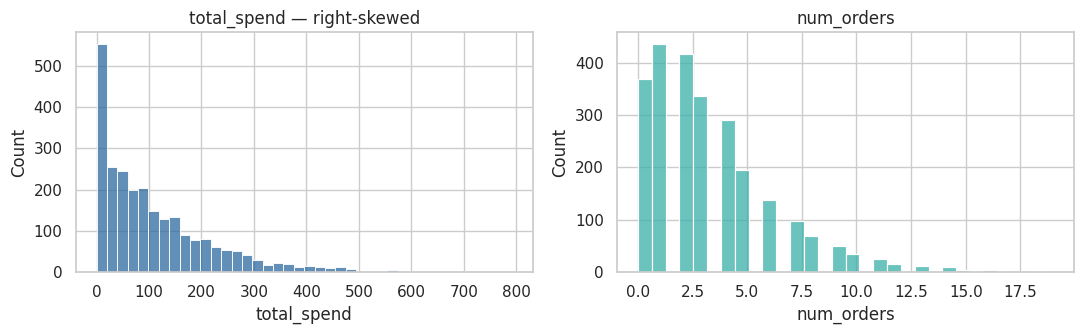

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. DISTRIBUTION OF SPEND  (note the long right tail)
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df['total_spend'], bins=40, ax=ax[0], color='#2D6A9F')
ax[0].set_title('total_spend — right-skewed')
sns.histplot(df['num_orders'], bins=30, ax=ax[1], color='#3AAFA9')
ax[1].set_title('num_orders')
plt.tight_layout(); plt.show()

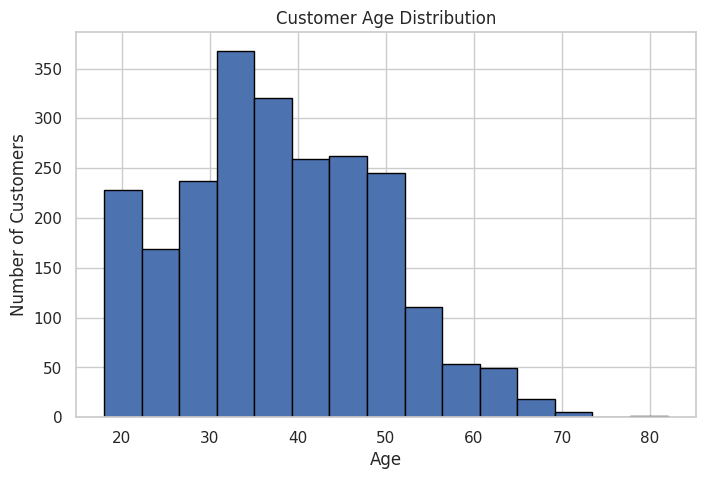

In [ ]:
# 1. Histogram of age (drop missing values)
plt.figure(figsize=(8, 5))
df['age'].dropna().hist(bins=15, edgecolor='black')

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

# 2. Shape description:
# - The age distribution is roughly bell-shaped (approximately normal).
# - Most customers are concentrated around the 30–45 age range.
# - There may be a slight skew because ages are clipped between 18 and 82.
# - No impossible values (such as negative ages or ages above 100) are expected.
# - A small number of age values are missing and were excluded from the plot.

# Alternatively, using Seaborn:

# plt.figure(figsize=(8,5))
# sns.histplot(df['age'].dropna(), bins=15, kde=True)

# plt.title('Customer Age Distribution')
# plt.xlabel('Age')
# plt.ylabel('Count')
# plt.show()

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. MEAN vs MEDIAN ON A SKEWED COLUMN
# -----------------------------------------------------------
# When data is right-skewed, the mean is pulled up by big spenders.
spend = df['total_spend']
print('mean  :', round(spend.mean(), 1))
print('median:', round(spend.median(), 1))
print('skew  :', round(spend.skew(), 2), ' (> 0 means right-skewed)')
print('\nThe mean > median gap is the skew talking.')

mean  : 112.3
median: 79.1
skew  : 1.73  (> 0 means right-skewed)

The mean > median gap is the skew talking.


In [ ]:
# 1. Skew of the two columns
print("Skew of num_orders  :", df['num_orders'].skew())
print("Skew of total_spend :", df['total_spend'].skew())

# Optional: compare mean and median
print("\nnum_orders")
print("Mean   :", df['num_orders'].mean())
print("Median :", df['num_orders'].median())

print("\ntotal_spend")
print("Mean   :", df['total_spend'].mean())
print("Median :", df['total_spend'].median())

Skew of num_orders  : 1.35301053502581
Skew of total_spend : 1.731732234873782

num_orders
Mean   : 3.2608
Median : 3.0

total_spend
Mean   : 112.2729
Median : 79.12


In [ ]:
 # LAB EXERCISE 3 — Which average should finance report?
# Compute the skew of num_orders and total_spend.
# For each, decide whether mean or median better represents a 'typical' customer.
# Write your recommendation in a comment.

# 1. skew of the two columns
print(f"Skew of num_orders: {df['num_orders'].skew():.2f}")
print(f"Skew of total_spend: {df['total_spend'].skew():.2f}")

# 2 & 3. Which average for each, and why:
# For both 'num_orders' (skew ~1.35) and 'total_spend' (skew ~1.73),
# the skew values are significantly greater than 0, indicating a right-skewed distribution.
# This means there are a few customers with very high numbers of orders and very high total spending,
# pulling the mean upwards.
# Therefore, the **median** would be a better representation of a 'typical' customer for both `num_orders` and `total_spend`,
# as it is less affected by these extreme outliers compared to the mean.
# The mean would overstate the 'typical' value in these skewed distributions.

Skew of num_orders: 1.35
Skew of total_spend: 1.73


Plan mix:
plan
Basic       0.494
Standard    0.352
Premium     0.154
Name: proportion, dtype: float64

Top cities:
city
Mumbai       416
Delhi        405
Bengaluru    390
Hyderabad    320
Chennai      253
Name: count, dtype: int64


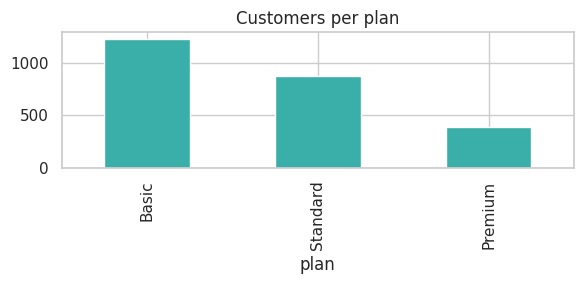

In [ ]:
print('Plan mix:')
print(df['plan'].value_counts(normalize=True).round(3))
print('\nTop cities:')
print(df['city'].value_counts().head(5))

fig, ax = plt.subplots(figsize=(6, 3))
df['plan'].value_counts().plot(kind='bar', ax=ax, color='#3AAFA9')
ax.set_title('Customers per plan'); plt.tight_layout(); plt.show()


Churn vs Retained Proportions:
is_churned
0    0.834
1    0.166
Name: proportion, dtype: float64

Retained customers : 2085
Churned customers  : 415
Imbalance Ratio (retained/churned): 5.02


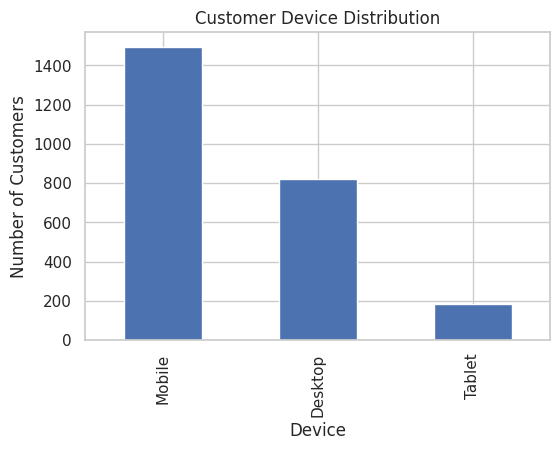

In [ ]:
churn_props = df['is_churned'].value_counts(normalize=True)
print("Churn vs Retained Proportions:")
print(churn_props)

# 2. Imbalance ratio (retained / churned)
retained = (df['is_churned'] == 0).sum()
churned = (df['is_churned'] == 1).sum()

imbalance_ratio = retained / churned
print("\nRetained customers :", retained)
print("Churned customers  :", churned)
print("Imbalance Ratio (retained/churned):", round(imbalance_ratio, 2))

# 3. Bar chart of device
plt.figure(figsize=(6, 4))
df['device'].value_counts().plot(kind='bar')

plt.title('Customer Device Distribution')
plt.xlabel('Device')
plt.ylabel('Number of Customers')
plt.show()

# Comment:
# - Mobile is expected to be the dominant category because the dataset
#   was generated with probabilities:
#       Mobile = 60%
#       Desktop = 32%
#       Tablet = 8%
# - Therefore, most customers access the platform using mobile devices.



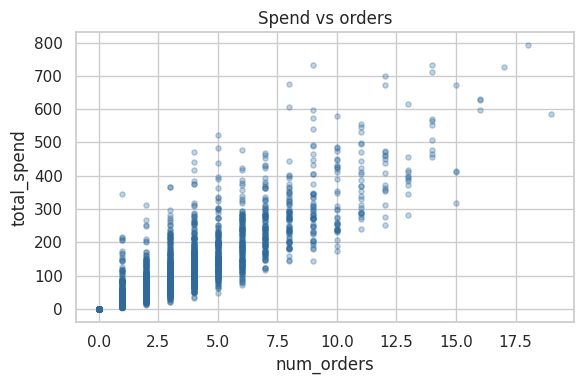

correlation: 0.864


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['num_orders'], df['total_spend'], alpha=0.3, color='#2D6A9F', s=14)
ax.set_xlabel('num_orders'); ax.set_ylabel('total_spend')
ax.set_title('Spend vs orders'); plt.tight_layout(); plt.show()

print('correlation:', round(df['num_orders'].corr(df['total_spend']), 3))


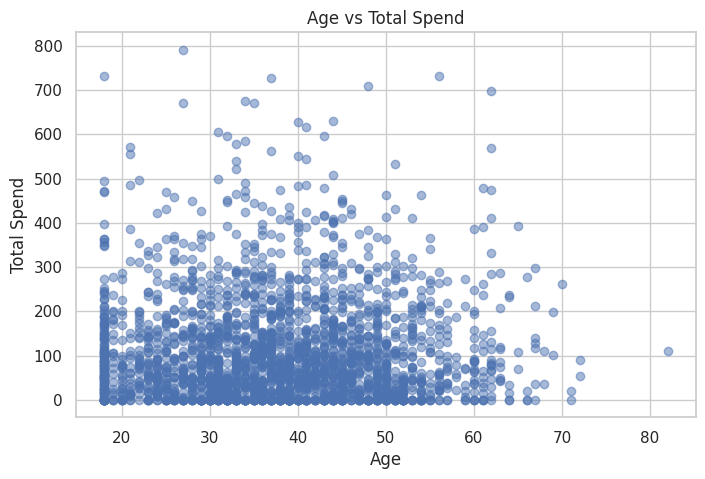

Correlation between age and total_spend: 0.007


In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['total_spend'], alpha=0.5)

plt.title('Age vs Total Spend')
plt.xlabel('Age')
plt.ylabel('Total Spend')
plt.show()

# 2. Correlation
corr = df[['age', 'total_spend']].corr().loc['age', 'total_spend']
print("Correlation between age and total_spend:", round(corr, 3))

# Alternative:
# corr = df['age'].corr(df['total_spend'])

# 3. Interpretation:
# - The correlation coefficient measures the strength of the linear relationship.
# - A value near 0 indicates little or no linear relationship.
# - A value close to +1 indicates a strong positive relationship.
# - A value close to -1 indicates a strong negative relationship.
# - In this synthetic dataset, age was generated independently of spending,
#   so the correlation is expected to be close to 0.
# - Therefore, age alone is unlikely to be a strong predictor of total spending.
# - Remember: correlation does not imply causation. Even if a correlation
#   exists, it does not prove that age causes customers to spend more or less.


            num_orders  total_spend  support_tickets
is_churned                                          
0                  3.6        125.5              0.6
1                  1.4         45.9              0.7


/tmp/ipykernel_2182/1126294479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,


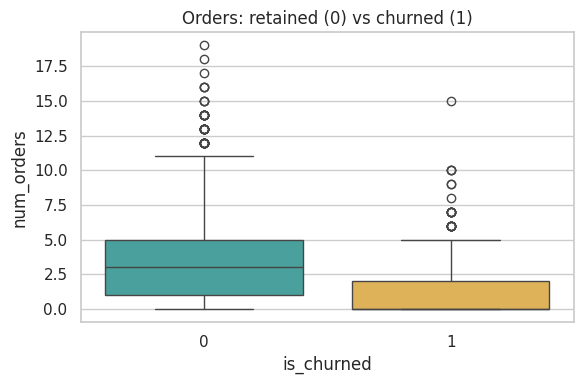

In [ ]:
cols = ['num_orders', 'total_spend', 'support_tickets']
print(df.groupby('is_churned')[cols].mean().round(1))

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,
            palette=['#3AAFA9', '#F4B942'])
ax.set_title('Orders: retained (0) vs churned (1)')
plt.tight_layout(); plt.show()


Mean support tickets by churn status:
is_churned
0    0.58801
1    0.73253
Name: support_tickets, dtype: float64

Retained customers (0): 0.59
Churned customers (1): 0.73


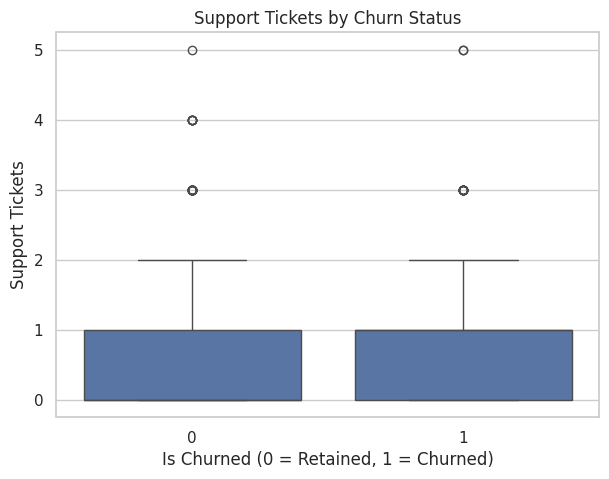

In [ ]:
# 1. Mean support_tickets by churn status
mean_tickets = df.groupby('is_churned')['support_tickets'].mean()
print("Mean support tickets by churn status:")
print(mean_tickets)

# Optional: clearer labels
print("\nRetained customers (0):",
      round(mean_tickets[0], 2))
print("Churned customers (1):",
      round(mean_tickets[1], 2))

# 2. Box plot of support_tickets by is_churned
plt.figure(figsize=(7, 5))
sns.boxplot(x='is_churned', y='support_tickets', data=df)

plt.title('Support Tickets by Churn Status')
plt.xlabel('Is Churned (0 = Retained, 1 = Churned)')
plt.ylabel('Support Tickets')
plt.show()

# 3. Interpretation:
# - Compare the average support_tickets for churned and retained customers.
# - If churned customers have a noticeably higher mean and median number
#   of tickets, support tickets may be a churn warning sign.
# - The box plot helps compare the distributions and identify whether
#   churners generally submit more tickets.
# - In this dataset, churn probability was generated partly using
#   support_tickets, so churned customers are expected to have more tickets
#   on average than retained customers.
# - Therefore, support tickets appear to be a useful predictor and a
#   potential warning sign of future churn.


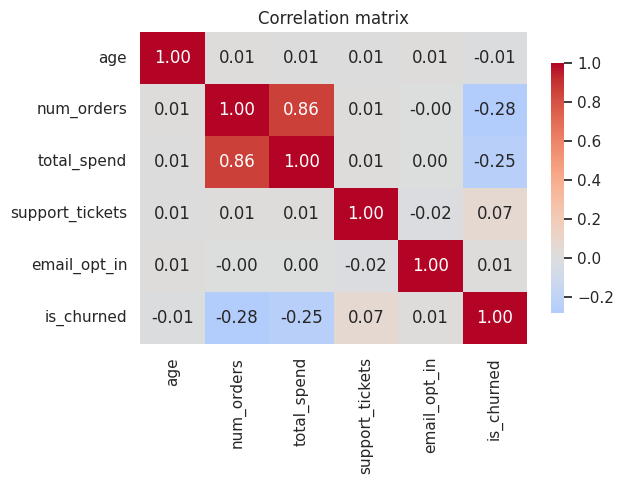

Correlation with churn (sorted):
num_orders        -0.282144
total_spend       -0.252546
age               -0.010746
email_opt_in       0.011145
support_tickets    0.068880
Name: is_churned, dtype: float64


In [ ]:
num = ['age', 'num_orders', 'total_spend', 'support_tickets',
       'email_opt_in', 'is_churned']
corr = df[num].corr()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Correlation matrix'); plt.tight_layout(); plt.show()

print('Correlation with churn (sorted):')
print(corr['is_churned'].drop('is_churned').sort_values())

In [ ]:
corr = df.corr(numeric_only=True)

top2 = (
    corr['is_churned']
    .drop('is_churned')
    .abs()
    .sort_values(ascending=False)
    .head(2)
)

print("Top 2 features most correlated with churn:")
print(top2)

# Also show the actual correlation values (with sign)
print("\nActual correlations:")
for feature in top2.index:
    print(f"{feature}: {corr.loc[feature, 'is_churned']:.3f}")

Top 2 features most correlated with churn:
num_orders     0.282144
total_spend    0.252546
Name: is_churned, dtype: float64

Actual correlations:
num_orders: -0.282
total_spend: -0.253


In [ ]:
print('Churn rate by plan:')
print(df.groupby('plan')['is_churned'].mean().round(3).sort_values(ascending=False))

print('\nChurn rate by device x plan:')
print(df.pivot_table(values='is_churned', index='plan',
                     columns='device', aggfunc='mean').round(3))


Churn rate by plan:
plan
Standard    0.174
Basic       0.163
Premium     0.158
Name: is_churned, dtype: float64

Churn rate by device x plan:
device    Desktop  Mobile  Tablet
plan                             
Basic       0.163   0.163   0.162
Premium     0.133   0.168   0.176
Standard    0.168   0.179   0.159


In [ ]:
# LAB EXERCISE 8 — Where is churn worst?

# 1. Churn rate by payment_method
churn_by_payment = df.groupby('payment_method')['is_churned'].mean()

print("Churn Rate by Payment Method:")
print(churn_by_payment.sort_values(ascending=False))

# 2. Pivot table: churn rate by plan x email_opt_in
pivot = pd.pivot_table(
    df,
    values='is_churned',
    index='plan',
    columns='email_opt_in',
    aggfunc='mean'
)

print("\nChurn Rate by Plan and Email Opt-In:")
print(pivot)

# Optional: format as percentages
print("\nAs Percentages:")
print((pivot * 100).round(2))

# 3. Worst-churning segment
worst_rate = pivot.max().max()
worst_segment = pivot.stack().idxmax()

print("\nWorst-Churning Segment:")
print(f"Plan = {worst_segment[0]}, Email Opt-In = {worst_segment[1]}")
print(f"Churn Rate = {worst_rate:.3f}")

Churn Rate by Payment Method:
payment_method
Card          0.175097
UPI           0.168998
NetBanking    0.150943
Wallet        0.143266
Name: is_churned, dtype: float64

Churn Rate by Plan and Email Opt-In:
email_opt_in         0         1
plan                            
Basic         0.157407  0.165835
Premium       0.170370  0.151394
Standard      0.159864  0.180887

As Percentages:
email_opt_in      0      1
plan                      
Basic         15.74  16.58
Premium       17.04  15.14
Standard      15.99  18.09

Worst-Churning Segment:
Plan = Standard, Email Opt-In = 1
Churn Rate = 0.181


In [ ]:

# -----------------------------------------------------------
# 🔹 9A. OUTLIERS IN SPEND (IQR rule)
# -----------------------------------------------------------
q1, q3 = df['total_spend'].quantile([0.25, 0.75])
iqr = q3 - q1
high = q3 + 1.5 * iqr
outliers = df[df['total_spend'] > high]
print(f'IQR upper bound: {high:.0f}')
print('Whale customers above it:', len(outliers))
print(outliers[['customer_id', 'num_orders', 'total_spend']]
      .sort_values('total_spend', ascending=False).head())

IQR upper bound: 365
Whale customers above it: 110
     customer_id  num_orders  total_spend
812    CUST00813          18       791.37
1176   CUST01177          14       732.79
875    CUST00876           9       732.24
562    CUST00563          17       727.37
768    CUST00769          14       710.47
